In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../datasets/raw/diabetes.csv")
print(df.shape)

(100000, 9)


In [3]:
print(df.columns)
print(df.info())
print(df.describe().T)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None
                        count        mean        std    min     25%     50%  \
age                  100000.0   41.8858

* Check for Duplicates

In [4]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 3854


**drop duplicates**

In [5]:
df.drop_duplicates()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


* Uniqueness

In [6]:
for column in df.columns:
    distinct = len(df[column].unique())
    print(f"{column}: {distinct} distinct values")

gender: 3 distinct values
age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
smoking_history: 6 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values


### Univariate Analysis

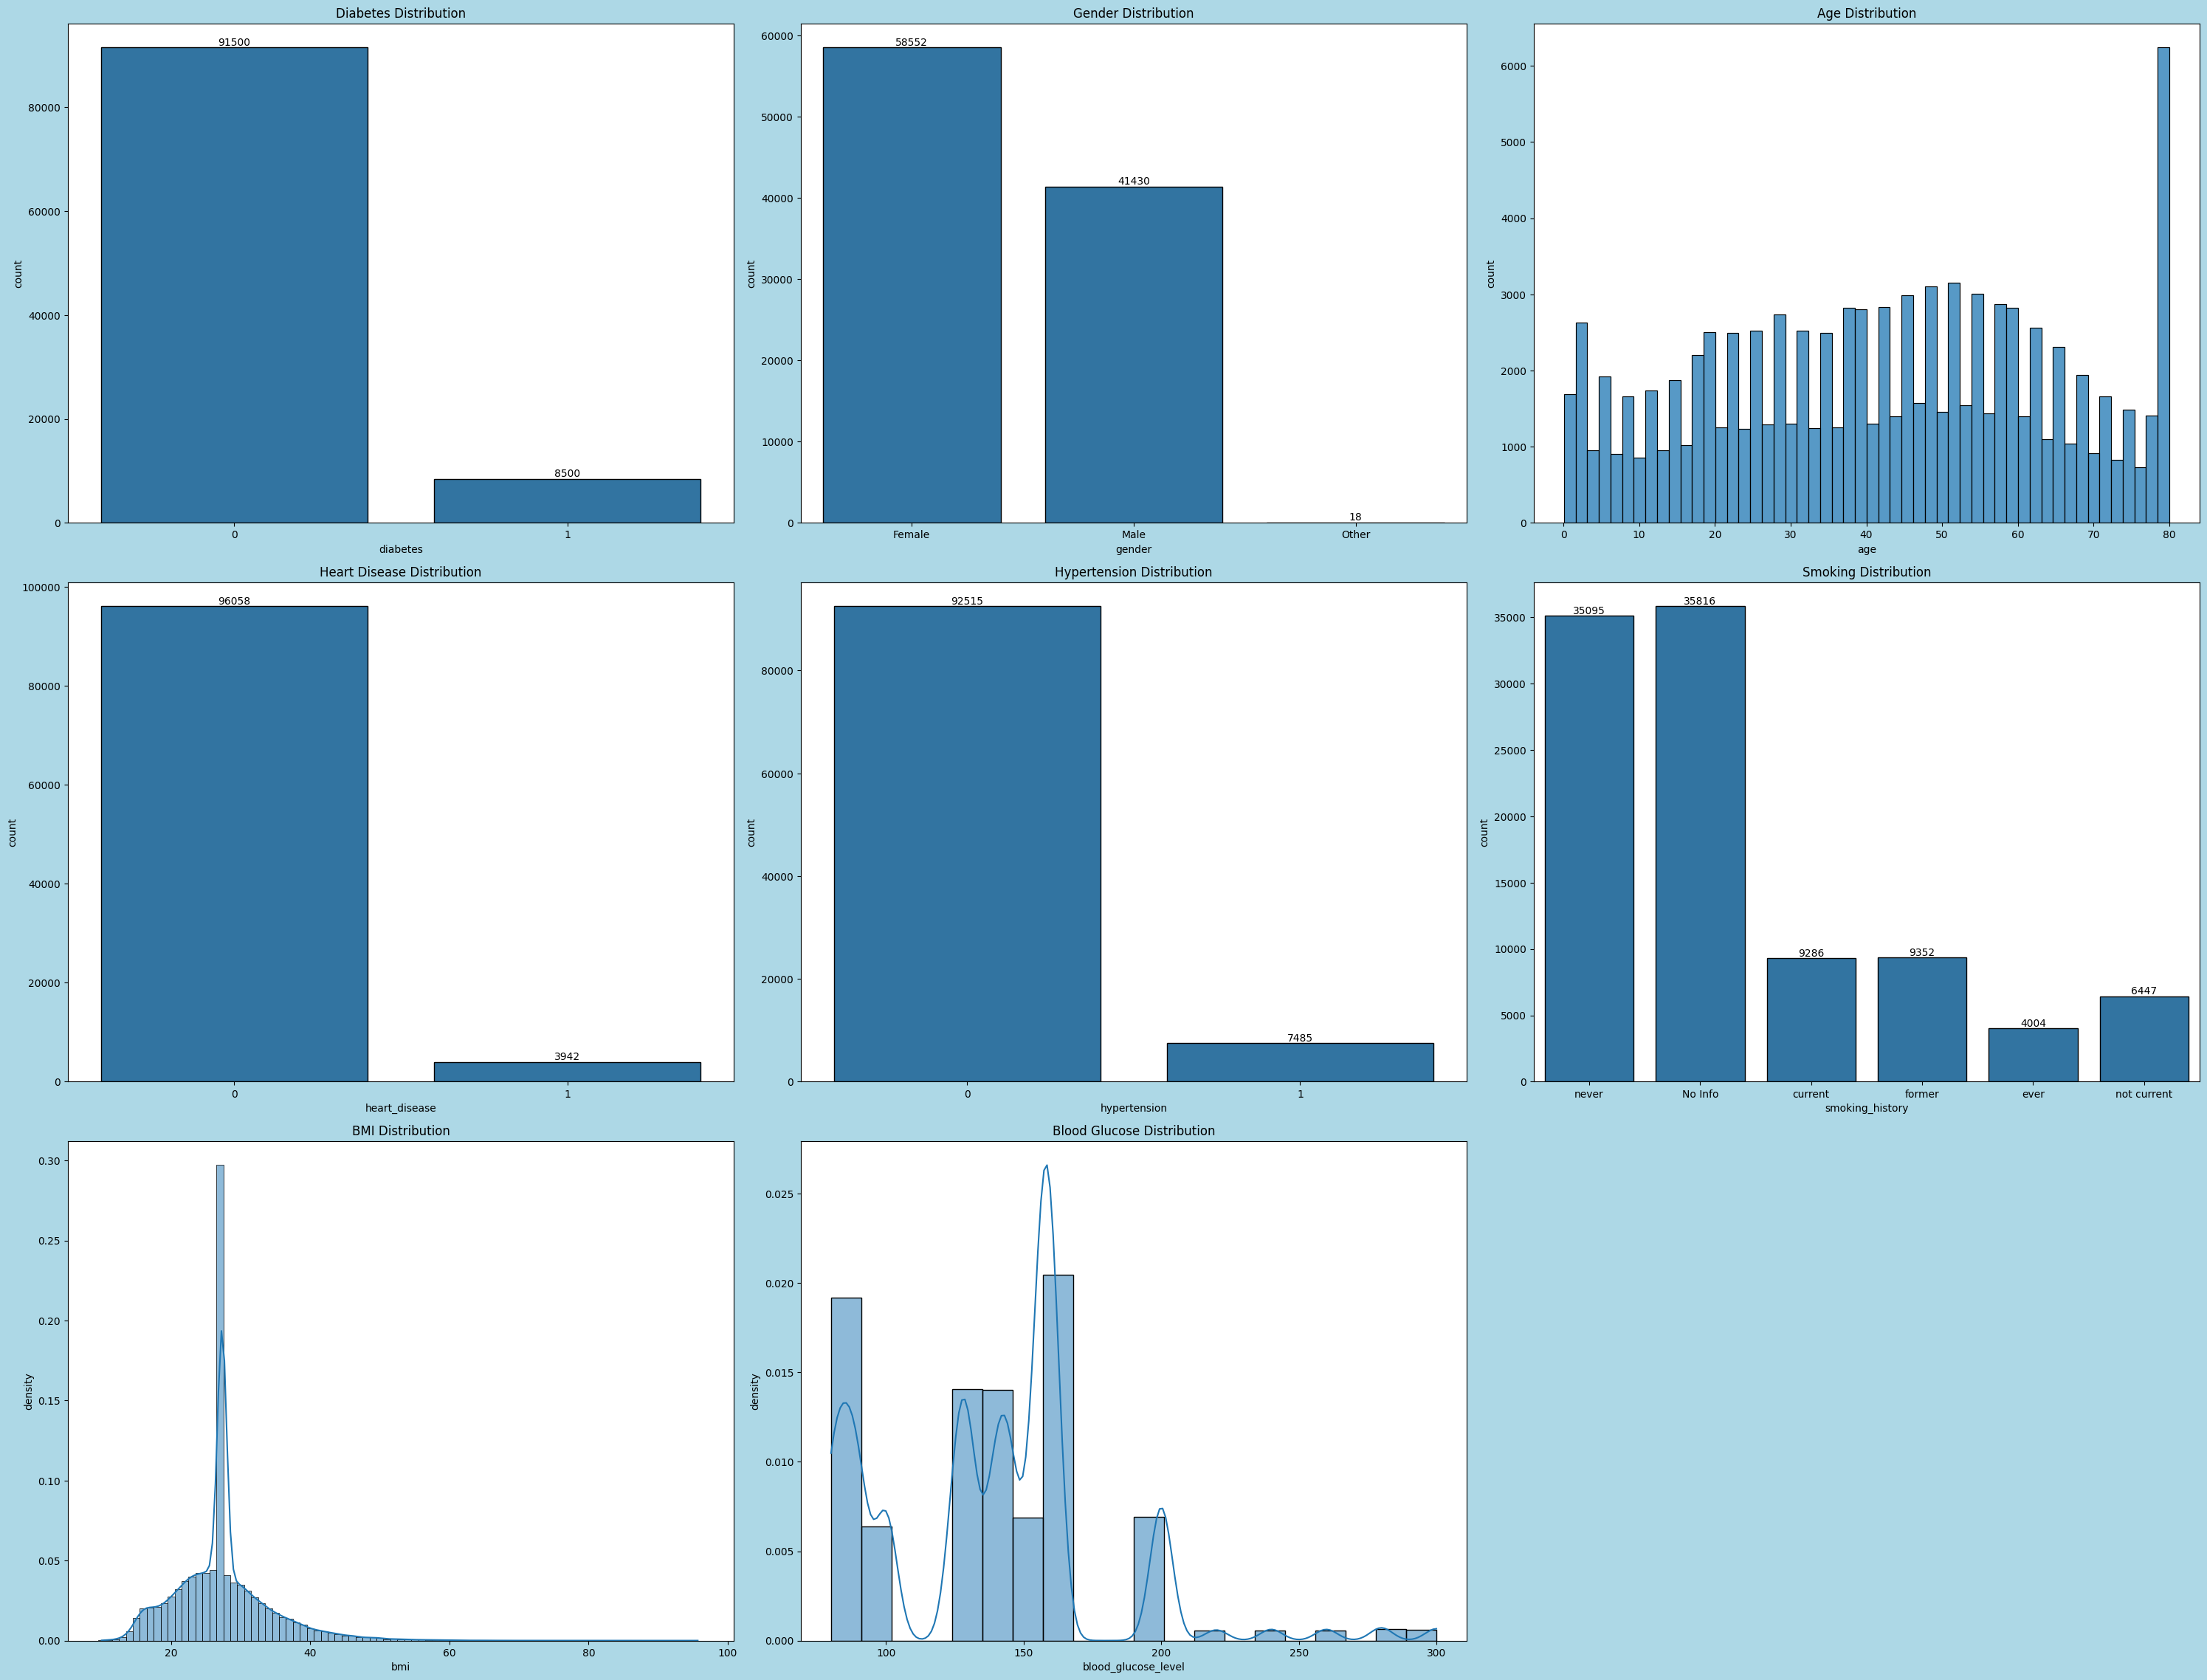

In [7]:
plt.figure(figsize=(30,30), facecolor="lightblue")

plt.subplot(4,3,1)
ax = sns.countplot(data=df, x="diabetes", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Diabetes Distribution")

plt.subplot(4,3,2)
ax = sns.countplot(data=df, x="gender", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("gender")
plt.ylabel("count")
plt.title("Gender Distribution")

plt.subplot(4,3,3)
sns.histplot(data=df, x="age", edgecolor="black")
plt.xlabel("age")
plt.ylabel("count")
plt.title("Age Distribution")

plt.subplot(4,3,4)
ax = sns.countplot(data=df, x="heart_disease", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Heart Disease Distribution")

plt.subplot(4,3,5)
ax = sns.countplot(data=df, x="hypertension", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Hypertension Distribution")

plt.subplot(4,3,6)
ax = sns.countplot(data=df, x="smoking_history", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Smoking Distribution")

plt.subplot(4,3,7)
sns.histplot(data=df, x="bmi", discrete=True, stat="density", kde=True)
plt.xlabel("bmi")
plt.ylabel("density")
plt.title("BMI Distribution")

plt.subplot(4,3,8)
sns.histplot(data=df, x="blood_glucose_level", bins=20, stat="density", kde=True)
plt.xlabel("blood_glucose_level")
plt.ylabel("density")
plt.title("Blood Glucose Distribution")

plt.tight_layout()
plt.show()

### Bivariate Analysis

In [23]:
num_cols = (
    df.groupby("diabetes")
    [["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
    .agg(["mean", "median", "std"])
    .unstack()
)
print(num_cols)

                             diabetes
age                  mean    0            40.115187
                             1            60.946588
                     median  0            40.000000
                             1            62.000000
                     std     0            22.306005
                             1            14.549880
bmi                  mean    0            26.887163
                             1            31.988382
                     median  0            27.320000
                             1            29.970000
                     std     0             6.373406
                             1             7.558371
HbA1c_level          mean    0             5.396761
                             1             6.934953
                     median  0             5.800000
                             1             6.600000
                     std     0             0.971628
                             1             1.076562
blood_glucose_level  mean 

In [8]:
gender_diabetes = (
    df.groupby("gender")["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(gender_diabetes)

        Diabetes Rate  Total
gender                      
Female       0.076189  58552
Male         0.097490  41430
Other        0.000000     18


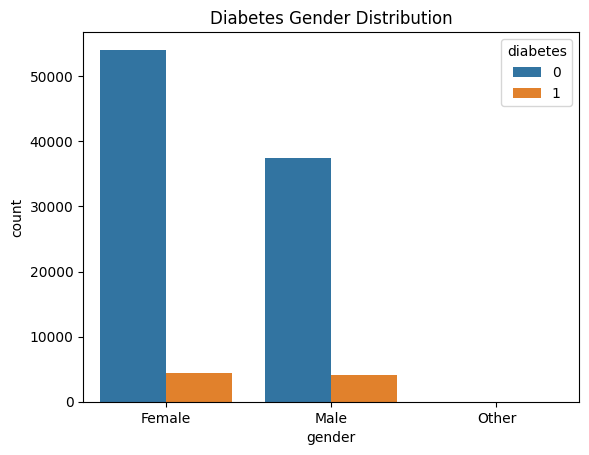

In [9]:
sns.countplot(data=df, x="gender", hue="diabetes")
plt.title("Diabetes Gender Distribution")
plt.show()

In [10]:
smoking_gender = (
    df.groupby(["gender", "smoking_history"])["diabetes"]
    .agg(["mean", "count"])
    .rename(columns={"mean":"Diabetes Rate", "count":"Total"})
    )
print(smoking_gender)

                        Diabetes Rate  Total
gender smoking_history                      
Female No Info               0.038274  19700
       current               0.089166   5058
       ever                  0.094281   2238
       former                0.135945   4774
       never                 0.087542  22869
       not current           0.100690   3913
Male   No Info               0.043451  16110
       current               0.117550   4228
       ever                  0.147875   1765
       former                0.205548   4578
       never                 0.109957  12223
       not current           0.117181   2526
Other  No Info               0.000000      6
       ever                  0.000000      1
       never                 0.000000      3
       not current           0.000000      8


   smoking_history  gender  diabetes
0          No Info  Female  0.038274
1          No Info    Male  0.043451
2          No Info   Other  0.000000
3          current  Female  0.089166
4          current    Male  0.117550
5             ever  Female  0.094281
6             ever    Male  0.147875
7             ever   Other  0.000000
8           former  Female  0.135945
9           former    Male  0.205548
10           never  Female  0.087542
11           never    Male  0.109957
12           never   Other  0.000000
13     not current  Female  0.100690
14     not current    Male  0.117181
15     not current   Other  0.000000


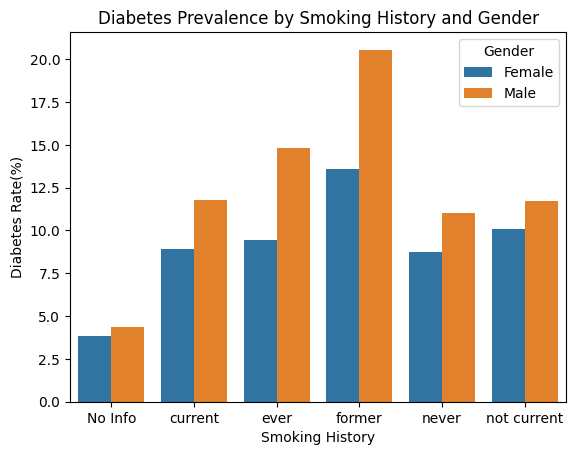

In [11]:
smoking_gender = (
    df.groupby(["smoking_history", "gender"])["diabetes"]
      .mean()
      .reset_index()
)
smoking_gender["diabetes"] *= 100
smoking_gender = smoking_gender[smoking_gender["gender"] != "Other"]
sns.barplot(data=smoking_gender, x="smoking_history", y="diabetes", hue="gender")
plt.title("Diabetes Prevalence by Smoking History and Gender")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes Rate(%)")
plt.legend(title="Gender")
plt.show()

* Diabetes prevalence varies across smoking-history categories, with former smokers showing the highest observed prevalence in both female and male groups. The pattern also differs across gender as within almost every comparable smoking category, males have a higher observed diabetes rate.

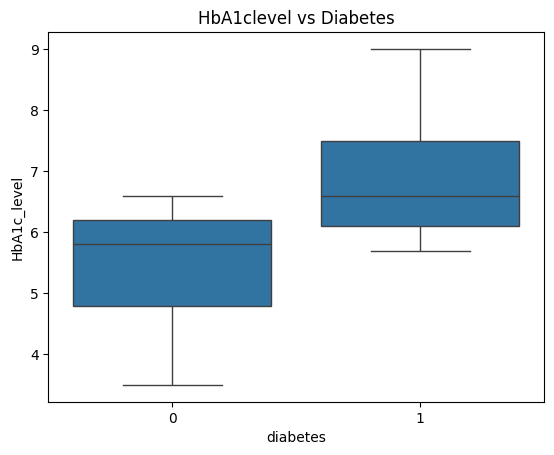

In [28]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level")
plt.title("HbA1clevel vs Diabetes")
plt.xlabel("diabetes")
plt.ylabel("HbA1c_level")
plt.show()

In [15]:
bmi_rate = (
    df.groupby([pd.cut(df["bmi"], bins=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]), "gender"])["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(bmi_rate)

                  Diabetes Rate  Total
bmi       gender                      
(10, 20]  Female       0.013982   6723
          Male         0.007014   5418
          Other        0.000000      3
(20, 30]  Female       0.054086  37681
          Male         0.078627  26683
          Other        0.000000      9
(30, 40]  Female       0.143341  10918
          Male         0.185664   7966
          Other        0.000000      6
(40, 50]  Female       0.223565   2648
          Male         0.312768   1167
(50, 60]  Female       0.286853    502
          Male         0.310559    161
(60, 70]  Female       0.333333     69
          Male         0.296296     27
(70, 80]  Female       0.375000      8
          Male         0.000000      2
(80, 90]  Female       0.666667      3
          Male         0.333333      3
(90, 100] Male         0.000000      3


In [ ]:
blood_glucose_bins = pd.cut(df["blood_glucose_level"], bins=[80, 100, 150, 200, 250, 300])
age_bins = pd.cut(df["age"], bins=[10, 20, 30, 50, 80, 100])
age_glucose_rate = (
    df.groupby([blood_glucose_bins, age_bins])["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(age_glucose_rate)

                              Diabetes Rate  Total
blood_glucose_level age                           
(80, 100]           (10, 20]       0.000000   2327
                    (20, 30]       0.000000   2863
                    (30, 50]       0.000000   6095
                    (50, 80]       0.000000   7331
(100, 150]          (10, 20]       0.009048   3205
                    (20, 30]       0.016936   3956
                    (30, 50]       0.058789   8556
                    (50, 80]       0.169794  11832
(150, 200]          (10, 20]       0.007387   3926
                    (20, 30]       0.010247   4977
                    (30, 50]       0.045446  10474
                    (50, 80]       0.143037  14290
(200, 250]          (10, 20]       1.000000      6
                    (20, 30]       1.000000     30
                    (30, 50]       1.000000    190
                    (50, 80]       1.000000   1008
(250, 300]          (10, 20]       1.000000     20
                    (20, 30]   

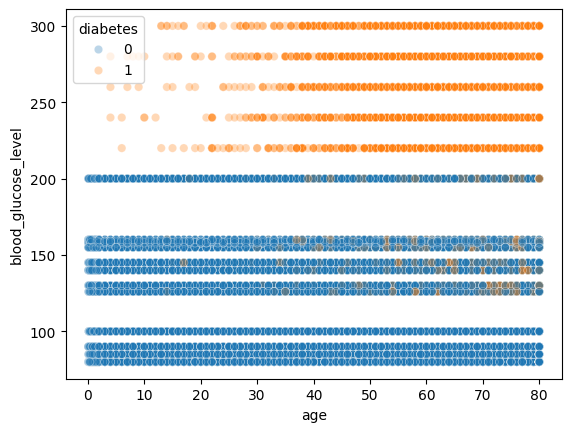

In [ ]:
sns.scatterplot(data=df, x="age", y="blood_glucose_level", hue="diabetes", alpha=0.3)
plt.title("age_glucose vs diabetes")
plt.show()

                          age  hypertension  heart_disease       bmi  \
age                  1.000000      0.251171       0.233354  0.337396   
hypertension         0.251171      1.000000       0.121262  0.147666   
heart_disease        0.233354      0.121262       1.000000  0.061198   
bmi                  0.337396      0.147666       0.061198  1.000000   
HbA1c_level          0.101354      0.080939       0.067589  0.082997   
blood_glucose_level  0.110672      0.084429       0.070066  0.091261   
diabetes             0.258008      0.197823       0.171727  0.214357   

                     HbA1c_level  blood_glucose_level  diabetes  
age                     0.101354             0.110672  0.258008  
hypertension            0.080939             0.084429  0.197823  
heart_disease           0.067589             0.070066  0.171727  
bmi                     0.082997             0.091261  0.214357  
HbA1c_level             1.000000             0.166733  0.400660  
blood_glucose_level     0.1

<function matplotlib.pyplot.show(close=None, block=None)>

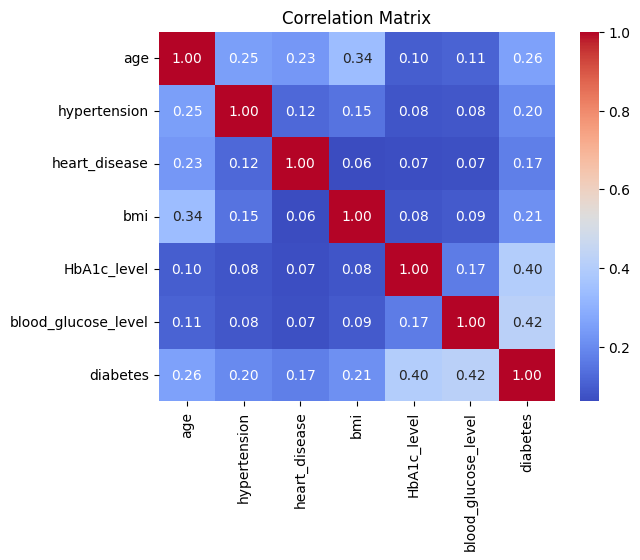

In [36]:
corr = df.select_dtypes(include="number").corr()
print(corr)
sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show